In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import os

In [6]:
# -------------------------------
# CSV files and table names
# -------------------------------
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')
]

# -------------------------------
# MySQL connection
# -------------------------------
conn = mysql.connector.connect(
    host='',
    port=,
    user='',
    password='',
    database='',
    autocommit=False,
    connection_timeout=600
)
cursor = conn.cursor()

# -------------------------------
# Folder path
# -------------------------------
folder_path = r''

# -------------------------------
# Pandas dtype → MySQL datatype
# -------------------------------
def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'DECIMAL(10,2)'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

# -------------------------------
# Insert chunk size
# -------------------------------
CHUNK_SIZE = 1000

# -------------------------------
# Main loop
# -------------------------------
for csv_file, table_name in csv_files:
    print(f"\nProcessing: {csv_file}")

    file_path = os.path.join(folder_path, csv_file)
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'\s+', '_', regex=True)
        .str.replace('-', '_')
        .str.replace('.', '_')
    )

    # Replace NaN with None
    df = df.replace({np.nan: None})

    # -------------------------------
    # Create table
    # -------------------------------
    columns_sql = ", ".join(
        f"`{col}` {get_sql_type(df[col].dtype)}"
        for col in df.columns
    )

    create_table_query = f"""
        CREATE TABLE IF NOT EXISTS `{table_name}` (
            {columns_sql}
        )
    """
    cursor.execute(create_table_query)
    conn.commit()

    # -------------------------------
    # Insert query
    # -------------------------------
    placeholders = ", ".join(["%s"] * len(df.columns))
    insert_query = f"""
        INSERT INTO `{table_name}`
        ({', '.join(f'`{col}`' for col in df.columns)})
        VALUES ({placeholders})
    """

    # -------------------------------
    # Insert data in chunks
    # -------------------------------
    total_rows = len(df)

    for start in range(0, total_rows, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, total_rows)
        chunk = df.iloc[start:end]

        data = [
            tuple(None if pd.isna(x) else x for x in row)
            for row in chunk.itertuples(index=False, name=None)
        ]

        cursor.executemany(insert_query, data)
        conn.commit()

        print(f"Inserted rows {start + 1} to {end}")

    print(f"✅ Finished `{table_name}`")

# -------------------------------
# Close connection
# -------------------------------
cursor.close()
conn.close()

print("\n🎉 ALL FILES LOADED SUCCESSFULLY")



Processing: customers.csv
Inserted rows 1 to 1000
Inserted rows 1001 to 2000
Inserted rows 2001 to 3000
Inserted rows 3001 to 4000
Inserted rows 4001 to 5000
Inserted rows 5001 to 6000
Inserted rows 6001 to 7000
Inserted rows 7001 to 8000
Inserted rows 8001 to 9000
Inserted rows 9001 to 10000
Inserted rows 10001 to 11000
Inserted rows 11001 to 12000
Inserted rows 12001 to 13000
Inserted rows 13001 to 14000
Inserted rows 14001 to 15000
Inserted rows 15001 to 16000
Inserted rows 16001 to 17000
Inserted rows 17001 to 18000
Inserted rows 18001 to 19000
Inserted rows 19001 to 20000
Inserted rows 20001 to 21000
Inserted rows 21001 to 22000
Inserted rows 22001 to 23000
Inserted rows 23001 to 24000
Inserted rows 24001 to 25000
Inserted rows 25001 to 26000
Inserted rows 26001 to 27000
Inserted rows 27001 to 28000
Inserted rows 28001 to 29000
Inserted rows 29001 to 30000
Inserted rows 30001 to 31000
Inserted rows 31001 to 32000
Inserted rows 32001 to 33000
Inserted rows 33001 to 34000
Inserted 

In [7]:
db = mysql.connector.connect(host = '',
                             port = ,
                             username = '',
                             password = '',
                             database = '')

cur=db.cursor(buffered = True)


In [8]:
# 'db.cursor()' allows python to send SQL queries to the Database

In [9]:
#1) List all the distinct city where customer are located.
query = ''' select distinct customer_city from customers'''
cur.execute(query)
data=cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

In [7]:
#2) Count the number of orders placed in 2017
query=''' select count(order_id) from orders where order_purchase_timestamp=2017'''
cur.execute(query)
data = cur.fetchall()
"total orders placed in 2017 are", data[0][0]

('total orders placed in 2017 are', 90202)

In [8]:
#3) Find total sales per category
query = ''' select upper(p.product_category) , round(sum(ot.price),0) from products p join order_items ot ON p.product_id=ot.product_id group by p.product_category'''
cur.execute(query)
data=cur.fetchall()
data
#To insert this data into the DataFrame
df=pd.DataFrame(data,columns=['Category','Total_sales'])
df


,Category,Total_sales
0,HEALTH BEAUTY,5034725
1,SPORT LEISURE,3952196
2,COOL STUFF,2541163
3,COMPUTER ACCESSORIES,3647817
4,WATCHES PRESENT,4820023
...,...,...
69,FLOWERS,4440
70,KITCHEN PORTABLE AND FOOD COACH,15874
71,CITTE AND UPHACK FURNITURE,17472
72,HOUSE COMFORT 2,3041


In [9]:
#4) Calculate the percentage of orders paid in installments
query = '''select (sum(case when payment_installments >=1 then 1 else 0 end )
                    / count(*) )*100 as Ratio from payments where payment_installments is not null'''
cur.execute(query)
data=cur.fetchall()
'the percentage of orders placed in installments is',data[0][0]

('the percentage of orders placed in installments is', Decimal('99.9981'))

In [10]:
#we considered 1 also as an installment that's why our answer is 99.99%.
#if we do not consider one as an installment then we have 49% of the payments which are paid in installments.

In [11]:
#Count  the number of customers from each city
query='''select customer_city as City,count(customer_unique_id) as total_customers  from customers group by customer_city'''
cur.execute(query)
data=cur.fetchall()
data

[('franca', 322),
 ('sao bernardo do campo', 1876),
 ('sao paulo', 31080),
 ('mogi das cruzes', 766),
 ('campinas', 2888),
 ('jaragua do sul', 178),
 ('timoteo', 108),
 ('curitiba', 3042),
 ('belo horizonte', 5546),
 ('montes claros', 422),
 ('rio de janeiro', 13764),
 ('lencois paulista', 90),
 ('caxias do sul', 448),
 ('piracicaba', 738),
 ('guarulhos', 2378),
 ('pacaja', 12),
 ('florianopolis', 1140),
 ('aparecida de goiania', 220),
 ('santo andre', 1594),
 ('goiania', 1384),
 ('cachoeiro de itapemirim', 244),
 ('sao jose dos campos', 1382),
 ('sao roque', 158),
 ('camacari', 122),
 ('resende', 234),
 ('sumare', 366),
 ('novo hamburgo', 246),
 ('sao luis', 706),
 ('sao jose', 338),
 ('santa barbara', 52),
 ('ribeirao preto', 1020),
 ('ituiutaba', 112),
 ('taquarituba', 32),
 ('sao jose dos pinhais', 266),
 ('barrinha', 40),
 ('parati', 26),
 ('dourados', 128),
 ('trindade', 56),
 ('cascavel', 306),
 ('fortaleza', 1308),
 ('brasilia', 4262),
 ('pelotas', 372),
 ('porto alegre', 2758)

# Intermediate Queries

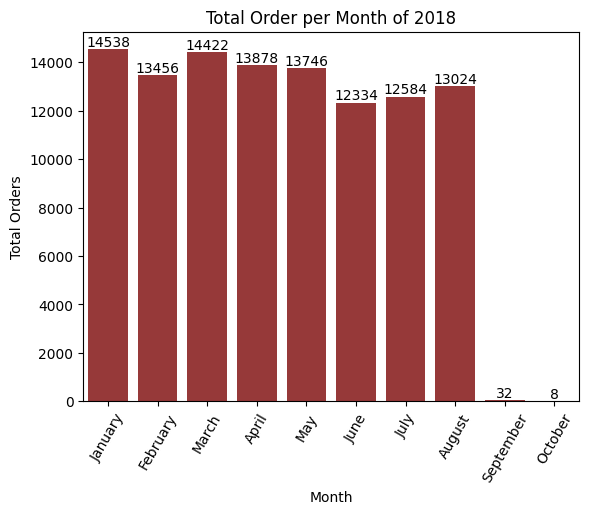

<Figure size 800x800 with 0 Axes>

In [12]:
#6) Calculate the total orders per month in the year of 2018
query='''select monthname(order_purchase_timestamp) as month_name , 
count(order_id) as count_of_orders 
from orders where order_purchase_timestamp=2018 
group by month_name; '''
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data, columns=["Month_name","Total_Orders"])
o=["January","February","March","April","May","June","July","August","September","October"]

ax=sns.barplot(x="Month_name",y="Total_Orders",data =df, order = o,color='brown')
plt.xticks(rotation=60)
ax.bar_label(ax.containers[0])
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.title('Total Order per Month of 2018')
plt.figure(figsize=(8,8))
plt.show()

In [13]:
#7) Count the average number of product per order, group by city
query=''' with count_per_order as 
(
select orders.order_id, orders.customer_id,count(order_items.order_id) as order_count
from orders join order_items on orders.order_id=order_items.order_id
group by orders.order_id, orders.customer_id
) 
select customers.customer_city, round(avg(count_per_order.order_count),1) as average_order
from customers join count_per_order 
on customers.customer_id=count_per_order.customer_id
group by customers.customer_city '''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=['City','Average order'])
df

,City,Average order
0,sao paulo,4.6
1,sao jose dos campos,4.6
2,porto alegre,4.7
3,indaial,4.5
4,treze tilias,5.1
...,...,...
4105,sambaiba,4.0
4106,guairaca,8.0
4107,japaratuba,4.0
4108,tuiuti,4.0


In [17]:
#8)Calculate the percentage of total revenue contributed by each product category
query=''' select upper(products.product_category), round((sum(payments.payment_value)/ (select sum(payment_value) from payments))*100,3) contribution
from products join order_items on products.product_id=order_items.product_id 
join payments 
on payments.order_id=order_items.order_id
group by products.product_category order by contribution desc'''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=['Product Category','%Contribution'])
df

,Product Category,%Contribution
0,BED TABLE BATH,42.790
1,HEALTH BEAUTY,41.411
2,COMPUTER ACCESSORIES,39.611
3,FURNITURE DECORATION,35.735
4,WATCHES PRESENT,35.711
...,...,...
69,PC GAMER,0.054
70,HOUSE COMFORT 2,0.043
71,CDS MUSIC DVDS,0.030
72,FASHION CHILDREN'S CLOTHING,0.020


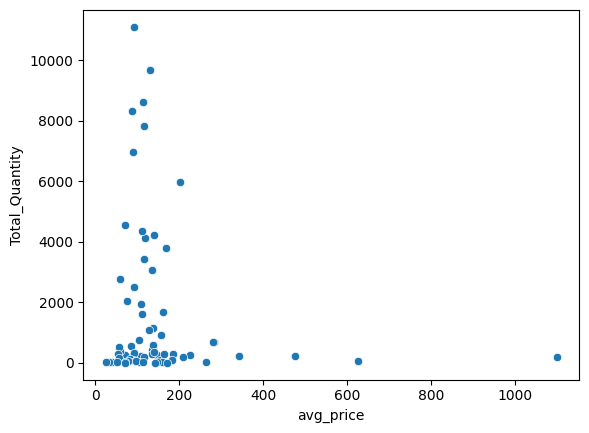

In [10]:
#8) Identify the coorelation between product price and number of times a product has been purchased
query = '''select products.product_category, avg(order_items.price) as avg_price,
count(order_items.order_id) as Total_Quantity
FROM products join order_items 
ON products.product_id=order_items.product_id
group by products.product_category;'''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns =['Product Category','avg_price','Total_Quantity'])

sns.scatterplot(x='avg_price',y='Total_Quantity',data=df)
plt.show()

In [16]:
#9) Calculate the total revenue generated by each seller, and rank them by revenue.
query=''' with rank_cte as 
(
select sellers.seller_id as Seller_ID, sellers.seller_city as Seller_City, sum(order_items.price) as Total_Earning
from sellers join order_items on sellers.seller_id=order_items.seller_id
group by sellers.seller_id, sellers.seller_city
)
select seller_id,Total_Earning, rank() over (order by Total_Earning desc) as rankingj
from rank_cte '''
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data, columns=['Seller_ID','Total_Earning','Seller_City','Ranking'])
df

,Seller_ID,Total_Earning,Seller_City,Ranking
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,guariba,1
1,53243585a1d6dc2643021fd1853d8905,222776.05,lauro de freitas,2
2,4a3ca9315b744ce9f8e9374361493884,200472.92,ibitinga,3
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,sumare,4
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,itaquaquecetuba,5
...,...,...,...,...
3090,34aefe746cd81b7f3b23253ea28bef39,8.00,curitiba,3091
3091,702835e4b785b67a084280efca355756,7.60,juiz de fora,3092
3092,1fa2d3def6adfa70e58c276bb64fe5bb,6.90,sao paulo,3093
3093,77128dec4bec4878c37ab7d6169d6f26,6.50,sao paulo,3094


In [20]:
#11) Calculate moving values of order value for each customer over their order history
query = ''' select customer_id, order_purchase_timestamp, payment_value,
avg(payment_value) over (partition by customer_id order by order_purchase_timestamp) as mov_avg
from 
(
select orders.customer_id, orders.order_purchase_timestamp, payments.payment_value
from payments join orders ON payments.order_id=orders.order_id) as payment
 '''
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data, columns = ['Customer_Id','Order_Timestamp','Payment_value','Mov_avg'])
df.head()

,Customer_Id,Order_Timestamp,Payment_value,Mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.740000
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410000
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.420000
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350000
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010000


In [29]:
#12) Calculate cumulative sum of each month for each year
query = ''' WITH monthly_data AS (
    SELECT 
        YEAR(o.order_purchase_timestamp) AS year_num,
        MONTHNAME(o.order_purchase_timestamp) AS month_name,
        SUM(p.payment_value) AS monthly_total
    FROM payments p
    JOIN orders o 
        ON p.order_id = o.order_id
    GROUP BY year_num, month_name
)

SELECT 
    year_num,
    month_name,
    SUM(monthly_total) 
        OVER (ORDER BY year_num, month_name) AS cumulative_total
FROM monthly_data '''
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data, columns=['Year','Month','Cumulative_Total'])
df

,Year,Month,Cumulative_Total
0,2016,December,19.62
1,2016,October,59110.10
2,2016,September,59362.34
3,2017,April,477150.37
4,2017,August,1151546.69
5,2017,December,2029948.17
6,2017,February,2321856.18
7,2017,January,2460344.22
8,2017,July,3052727.14
9,2017,June,3564003.52


In [33]:
#13) Calculate the year over year growth rate of total class
query = ''' with YOY_cte as 
(
select year(orders.order_purchase_timestamp) as year_, sum(payments.payment_value) as Total_Purchase
from orders join payments 
on orders.order_id=payments.order_id 
group by year_
)
select year_,((Total_Purchase - lag(Total_Purchase,1) over (order by year_))/lag(Total_Purchase,1) over (order by year_))*100 previous_year from YOY_cte 
    '''
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=['Year','YOY Growth'])
df

,Year,YOY Growth
0,2016,None
1,2017,12112.703761
2,2018,20.000924


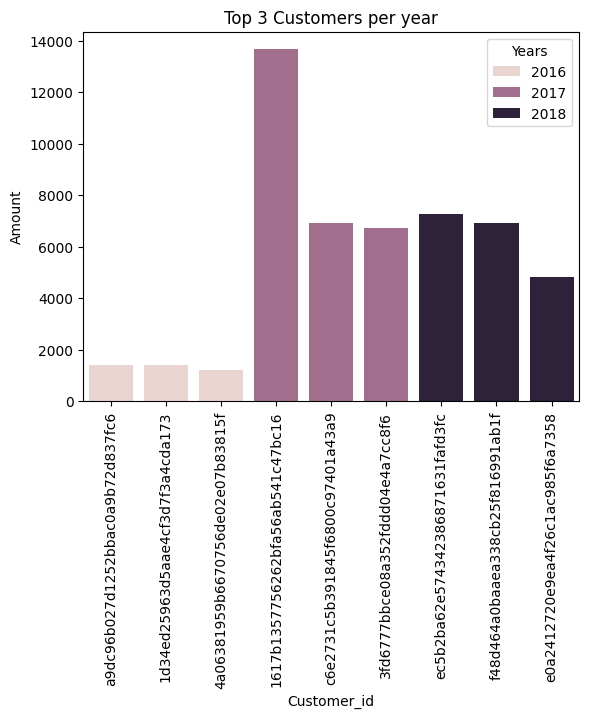

In [42]:
#14) Identify the top 3 customers who spent the most money in each year
query = ''' WITH yearly_customer_revenue AS (
    SELECT 
        YEAR(o.order_purchase_timestamp) AS year_,
        c.customer_id,
        SUM(p.payment_value) AS total_amount
    FROM customers c
    JOIN orders o 
        ON c.customer_id = o.customer_id
    JOIN payments p 
        ON o.order_id = p.order_id
    GROUP BY year_, c.customer_id
)

SELECT *
FROM (
    SELECT 
        year_,
        customer_id,
        total_amount,
        RANK() OVER (PARTITION BY year_ ORDER BY total_amount DESC) AS ranking
    FROM yearly_customer_revenue
) ranked_data
WHERE ranking <= 3
ORDER BY year_, ranking; '''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data, columns=['Years','Customer_id','Amount','Rank'])
sns.barplot(x='Customer_id',y='Amount',data=df,hue='Years')
plt.xticks(rotation=90)
plt.xlabel('Customer_id')
plt.ylabel('Amount')
plt.title('Top 3 Customers per year')
plt.show()